# 02 · Regional analysis: where is the shift fastest or slowest, and why?

**Business question:** How fast is Sweden shifting to battery-electric cars among private buyers, where is it fastest or slowest and why, and what BEV share is plausible by 2028?

This notebook covers **where and why**. It compares Sweden's 21 counties (län) on the private BEV share, looks at how each county moved through the bonus surge, the post-bonus fall and the 2026 restart, and tests which county characteristics go with higher shares.

Notebook 01 established the national pattern: private BEV share rose from 21% (2021) to 39% (2022), fell to about 32% in 2024–25, and is 38.6% in Jan–Aug 2026.

## 1. Setup and data

**Choices made here**
- **Private buyers only** (see `CLAUDE.md`). Company and leasing cars are registered in the lessor's county: Stockholm has **about half of all company registrations but under a quarter of private ones** (printed below). Dealer registrations are demo cars. Neither shows where households buy.
- **Periods:** full calendar years 2021–2025, plus **Jan–Aug 2025 and Jan–Aug 2026**, so that 2026 is compared with the same months a year earlier (the seasonality shown in 01).
- **County `99` (Unknown)** is excluded. It has essentially no private registrations (company and dealer cars only).
- **Ratios of sums** throughout: county-period share = BEV registrations ÷ all registrations in that county and period.
- Private-buyer data starts in 2021, so this notebook can't go further back. The 2010–2020 county series covers all owners and would mix in the leasing distortion.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import viz
from viz import BLUE, ORANGE, AQUA, RED, INK, INK2, MUTED, AXIS, GREY_DARK, GREY_LIGHT, SURFACE, PCT
viz.apply_style()
PROC, FIGS = ROOT / "data" / "processed", ROOT / "docs" / "figures"

fact = pd.read_csv(PROC / "fact_registrations_county_monthly.csv", parse_dates=["month"], dtype={"county_code": str})
panel = pd.read_csv(PROC / "county_year_panel.csv", dtype={"county_code": str})

priv = fact[(fact.owner_type == "private") & (fact.county_code != "99")].copy()
LAST = priv.month.max()
priv["year"] = priv.month.dt.year
comp = fact[fact.owner_type == "company"]
print(f"Stockholm's share of company registrations: {comp[comp.county_code == '01'].registrations.sum() / comp.registrations.sum():.1%}"
      f" vs private: {priv[priv.county_code == '01'].registrations.sum() / priv.registrations.sum():.1%}")
print(f"Unknown-county share of private registrations: "
      f"{fact[(fact.owner_type == 'private') & (fact.county_code == '99')].registrations.sum() / fact[fact.owner_type == 'private'].registrations.sum():.3%}")

def county_period(df):
    t = df.pivot_table(index=["county_name", "year"], columns="fuel_type", values="registrations",
                       aggfunc="sum", fill_value=0)
    t["total"] = t.sum(axis=1)
    return t

cy = county_period(priv[priv.year < LAST.year])                     # full years 2021-2025
ytd = county_period(priv[priv.month.dt.month <= LAST.month])        # Jan-Aug every year
YTD_PREV, YTD_CUR = f"Jan–{LAST:%b} {LAST.year - 1}", f"Jan–{LAST:%b} {LAST.year}"

def shares(fuel):
    s = (cy[fuel] / cy.total).unstack()
    s.columns = s.columns.astype(str)
    y = (ytd[fuel] / ytd.total).unstack()
    s[YTD_PREV], s[YTD_CUR] = y[LAST.year - 1], y[LAST.year]
    return s

bev, phev = shares("BEV"), shares("PHEV")
vol = cy.total.unstack()
print(f"{bev.shape[0]} counties; private registrations in 2025 range from "
      f"{vol[2025].min():,.0f} ({vol[2025].idxmin()}) to {vol[2025].max():,.0f} ({vol[2025].idxmax()})")

Stockholm's share of company registrations: 50.8% vs private: 23.1%
Unknown-county share of private registrations: 0.000%
21 counties; private registrations in 2025 range from 356 (Gotland) to 23,211 (Stockholm)


## 2. Where is the private BEV share highest and lowest?

The heatmap shows every county and period and works as the table view for the rest of the notebook. Rows are sorted by 2025, the latest full year.

**Choice: an uncertainty band for the ranking.** A county with 356 private registrations a year (Gotland) can move several points by chance. The dot chart gives each county's 2025 share a 95% Wilson interval. It treats each year's buyers as a sample of the county's underlying tendency to buy a BEV. Where intervals overlap, the ranking between those counties isn't meaningful.

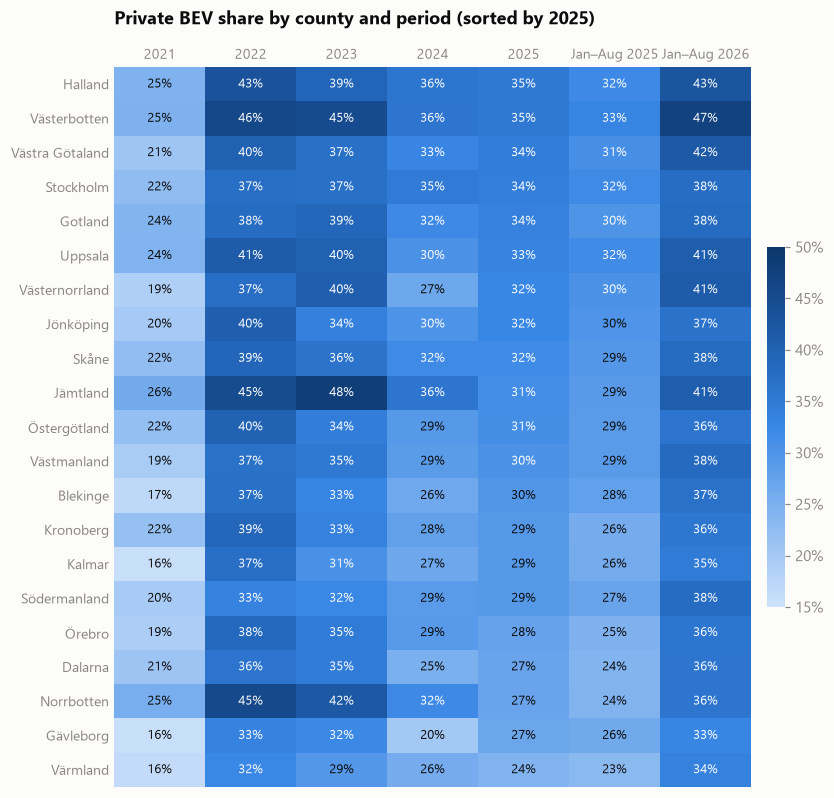

In [2]:
order = bev.sort_values("2025", ascending=False).index
H = bev.loc[order]

fig, ax = plt.subplots(figsize=(9, 8.5))
im = ax.imshow(H.values, cmap=viz.blue_cmap(), vmin=0.15, vmax=0.50, aspect="auto")
ax.set_xticks(range(H.shape[1]), H.columns, rotation=0, fontsize=9)
ax.set_yticks(range(H.shape[0]), H.index, fontsize=9)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False, length=0)
ax.tick_params(axis="y", length=0)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v = H.iat[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8.5, color="white" if v > 0.30 else INK)
ax.set_title("Private BEV share by county and period (sorted by 2025)", pad=28)
save_cb = fig.colorbar(im, ax=ax, format=PCT, shrink=0.5, pad=0.02)
save_cb.outline.set_visible(False)
viz.save(fig, "02_county_heatmap", FIGS)
plt.show()

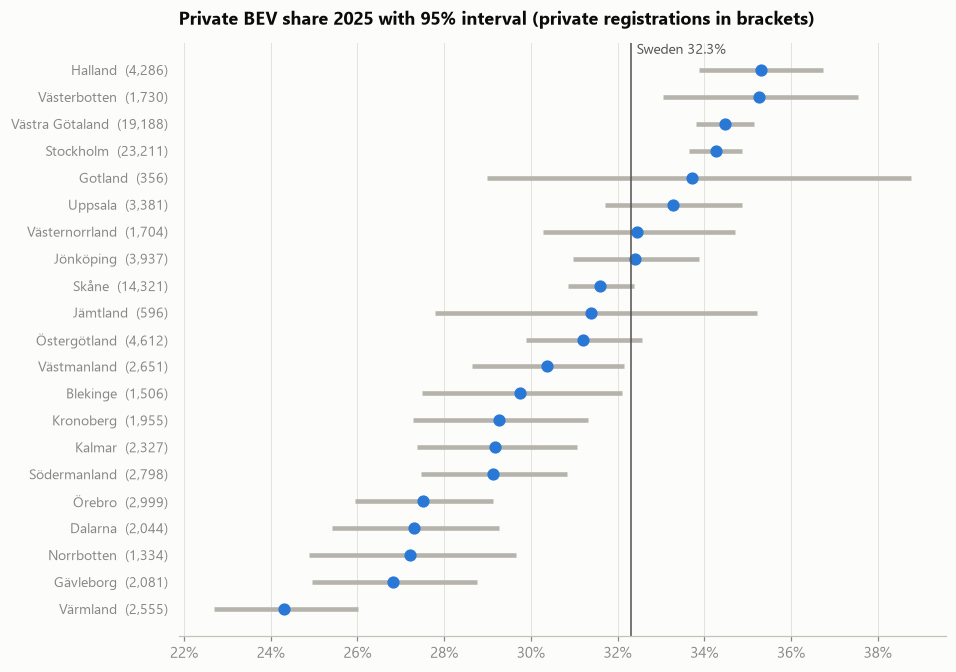

In [3]:
def wilson(k, n, z=1.96):
    p = k / n
    den = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return centre - half, centre + half

y25 = cy.xs(2025, level="year")
lo, hi = wilson(y25.BEV, y25.total)
d = pd.DataFrame({"share": y25.BEV / y25.total, "lo": lo, "hi": hi, "n": y25.total}).sort_values("share")
nat25 = y25.BEV.sum() / y25.total.sum()

fig, ax = plt.subplots(figsize=(9, 7))
yy = np.arange(len(d))
ax.hlines(yy, d.lo, d.hi, color=GREY_LIGHT, lw=3)
ax.plot(d.share, yy, "o", color=BLUE, ms=7)
ax.axvline(nat25, color=INK2, lw=1)
ax.annotate(f"Sweden {nat25:.1%}", (nat25, len(d) - 0.4), xytext=(4, 0), textcoords="offset points",
            fontsize=9, color=INK2)
ax.set_yticks(yy, [f"{c}  ({n:,.0f})" for c, n in zip(d.index, d.n)], fontsize=9)
ax.xaxis.set_major_formatter(PCT)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Private BEV share 2025 with 95% interval (private registrations in brackets)")
viz.save(fig, "02_county_ranking_2025", FIGS)
plt.show()

**What this shows**
- **Highest in 2025:** Halland and Västerbotten (35.3%), Västra Götaland (34.5%) and Stockholm (34.3%). **Lowest:** Värmland (24.3%), Gävleborg (26.8%), Norrbotten (27.2%) and Dalarna (27.3%). In Jan–Aug 2026 Västerbotten (47%) leads clearly, Stockholm has slipped to mid-table (38%), and Gävleborg and Värmland are still lowest (33–34%).
- **The 2025 spread is only about 11 pp from top to bottom.** Most of the middle counties have overlapping intervals, so their rank order is mostly noise. Only the ends of the ranking are clearly separated.
- **The leaders aren't simply the big-city counties.** Stockholm is 4th, Skåne (Malmö) is mid-table, and sparsely populated Västerbotten is joint first. The heatmap also shows that the far north (Norrbotten, Jämtland, Västerbotten) **led in 2021–22**, before Norrbotten and Jämtland fell well down the ranking.